In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.image as mpimg
import matplotlib.patches as patches

## 1. 每年各行业分布图

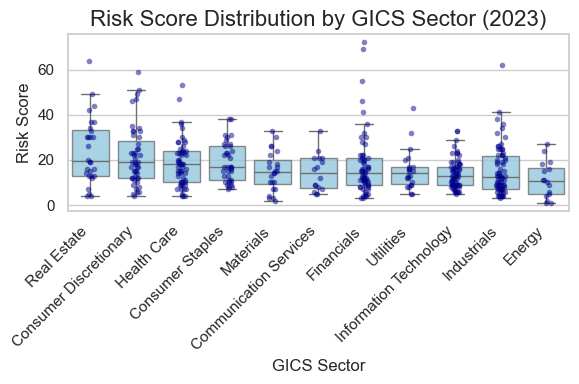

In [ ]:
year = 2023

df_risk_scores = pd.read_csv('./Data/Fama_French/risk_scores_item_1a_sum.csv')
df_year = df_risk_scores[df_risk_scores['year'] == year]
df_year_ticker = df_year['ticker'].unique()

df_info = pd.read_excel('./Data/S&P500_List_2025.xlsx')
df_info = df_info[['Symbol', 'GICS_Sector']]
df_info = df_info[df_info['Symbol'].isin(df_year_ticker)]

df_merged = pd.merge(df_year, df_info,
                     how='inner',
                     left_on='ticker',
                     right_on='Symbol')

median_scores = df_merged.groupby('GICS_Sector')['risk_score'].median().sort_values(ascending=False)
sector_order = median_scores.index

plt.figure(figsize=(6, 4))
sns.set_theme(style="whitegrid") # 设置一个美观的背景主题

sns.boxplot(
    x='GICS_Sector', 
    y='risk_score', 
    data=df_merged, 
    order=sector_order, 
    showfliers=False,    
    boxprops=dict(alpha=0.8),
    color="skyblue" 
)

sns.stripplot(
    x='GICS_Sector', 
    y='risk_score', 
    data=df_merged, 
    order=sector_order,
    jitter=True,       
    alpha=0.5,          
    color='darkblue', 
    size=4             
)

plt.xticks(rotation=45, ha='right', fontsize=11) # 旋转并对齐x轴标签
plt.xlabel('GICS Sector', fontsize=12)
plt.ylabel('Risk Score', fontsize=12)
plt.title(f'Risk Score Distribution by GICS Sector ({year})', fontsize=16)

plt.tight_layout() # 自动调整布局，防止标签重叠
plt.savefig(f'GICS_Sector_Risk_Score_{year}.png', dpi=300) # 保存图表
plt.show()

## 2. 分布趋势图

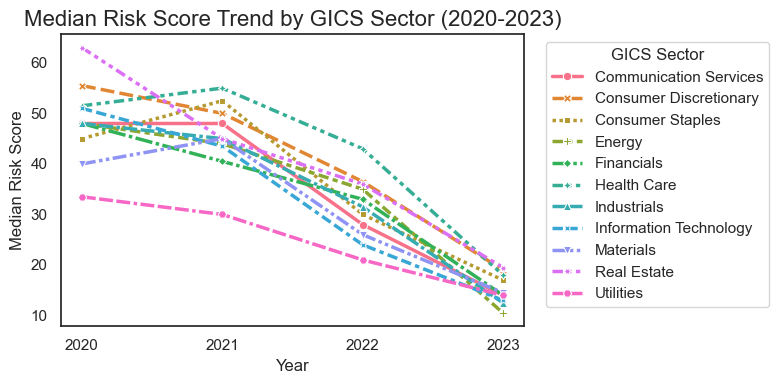

In [188]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator # 用于确保x轴为整数年份

# --- 数据准备 (与之前类似，但会选取多年数据) ---
df_risk_scores = pd.read_csv('./Data/Fama_French/risk_scores_item_1a_sum.csv')
df_info = pd.read_excel('./Data/S&P500_List_2025.xlsx')
df_info = df_info[['Symbol', 'GICS_Sector']]

# 1. 动态获取数据中最近的4个年份
# 这样代码更具通用性，无论数据如何更新都能找到最近4年
all_years = sorted(df_risk_scores['year'].unique())
years_to_plot = all_years[-4:] # 选取最后4个年份
start_year, end_year = years_to_plot[0], years_to_plot[-1]

# 2. 筛选这4年的风险数据
df_multi_year = df_risk_scores[df_risk_scores['year'].isin(years_to_plot)]

# 3. 与行业信息合并
df_merged = pd.merge(df_multi_year, df_info,
                     how='inner',
                     left_on='ticker',
                     right_on='Symbol')

# 4. (核心步骤) 按年份和行业分组，计算风险分数的中位数
df_trends = df_merged.groupby(['year', 'GICS_Sector'])['risk_score'].median().reset_index()

# --- 开始绘图 ---
plt.figure(figsize=(8, 4))
sns.set_theme(style="white") # 设置一个美观的背景主题

# 5. 使用 Seaborn 绘制折线图
# hue='GICS_Sector' 会为每个行业自动分配一种颜色的线条
ax = sns.lineplot(
    data=df_trends,
    x='year',
    y='risk_score',
    hue='GICS_Sector',
    style='GICS_Sector', # 使用不同线条样式，增强辨识度
    markers=True,      # 在每个数据点上添加标记
    linewidth=2.5
)

# --- 优化图表细节 ---
plt.title(f'Median Risk Score Trend by GICS Sector ({start_year}-{end_year})', fontsize=16)
plt.ylabel('Median Risk Score', fontsize=12)
plt.xlabel('Year', fontsize=12)

# 确保X轴显示为整数年份
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.xticks(rotation=0)

# 将图例放到图表外部，避免遮挡线条
plt.legend(bbox_to_anchor=(1.03, 1), loc='upper left', title='GICS Sector')

plt.tight_layout()
plt.show()

In [ ]:
## 3. 年度各行业趋势报告

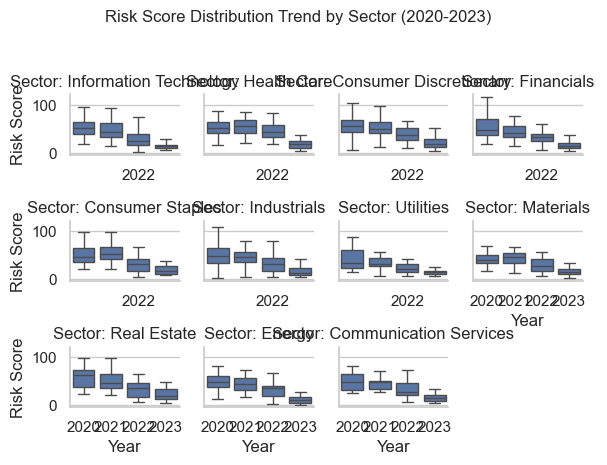

In [ ]:
g = sns.catplot(
    data=df_merged,
    x='year',          # 每个子图的X轴是年份
    y='risk_score',
    col='GICS_Sector', # 按行业来分面（分成不同列/子图）
    kind='box',        # 图表类型为箱形图
    col_wrap=4,        # 每行最多显示4个子图，让布局更美观
    height=1.5,          # 每个子图的高度
    aspect=1,        # 每个子图的宽高比
    showfliers=False   # 可以选择隐藏异常值让趋势更清晰
)

g.fig.suptitle(f'Risk Score Distribution Trend by Sector ({start_year}-{end_year})', y=1.03, fontsize=12)
g.set_axis_labels("Year", "Risk Score")
g.set_titles("Sector: {col_name}") # 设置每个子图的标题
g.fig.tight_layout(w_pad=1)

plt.show()

In [133]:
df_risk_scores = pd.read_csv('./Data/Fama_French/risk_scores_item_1a_sum.csv')

df_info = pd.read_excel('./Data/S&P500_List_2025.xlsx')
df_info = df_info[['Symbol', 'GICS_Sector']]
df_info = df_info[df_info['Symbol'].isin(df_risk_scores['ticker'])]

df_merged = pd.merge(df_risk_scores, df_info,
                     how='left',
                     left_on='ticker',
                     right_on='Symbol')

df_merged

,year,ticker,risk_score,Symbol,GICS_Sector
0,2020,AAPL,58,AAPL,Information Technology
1,2021,AAPL,85,AAPL,Information Technology
2,2022,AAPL,10,AAPL,Information Technology
3,2023,AAPL,7,AAPL,Information Technology
4,2020,ABBV,25,ABBV,Health Care
...,...,...,...,...,...
1697,2023,ZBRA,29,ZBRA,Information Technology
1698,2020,ZTS,84,ZTS,Health Care
1699,2021,ZTS,63,ZTS,Health Care
1700,2022,ZTS,63,ZTS,Health Care


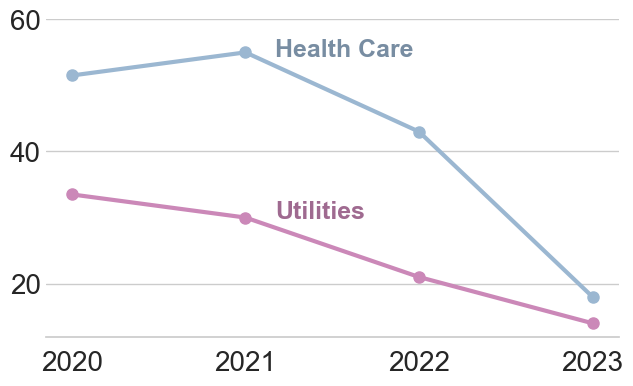

In [333]:
df_utilities = df_merged[df_merged['GICS_Sector'] == 'Utilities']
df_health_care = df_merged[df_merged['GICS_Sector'] == 'Health Care']

df_utilities.groupby('year')['risk_score'].median()
df_health_care.groupby('year')['risk_score'].median()

# 年份顺序（确保 x 轴顺序正确）
year_order = [2020, 2021, 2022, 2023]

# ======================= 2. 绘图 ==============================
sns.set_theme(style="whitegrid") # 设置一个美观的背景主题
fig,ax = plt.subplots(figsize=(6.5, 4))
ax.set_facecolor("#ffffff")  # 例如淡灰色
fig.patch.set_facecolor("#ffffff")  # 设置图表背景颜色，半透明

# 假设 year_order 是一个列表/Index，保证年份顺序
util_med = (df_utilities.groupby('year')['risk_score']
            .median()
            .reindex(year_order))         # 得到一个 Series，index=year, values=median

hc_med   = (df_health_care.groupby('year')['risk_score']
            .median()
            .reindex(year_order))

# 绘制：把 index 当作 x，values 当作 y
ax.plot(util_med.index, util_med.values,
        marker='o', label='Utilities',
        color="#CB88B8", linestyle='-', linewidth=3, markersize=8, alpha=1)

ax.plot(hc_med.index, hc_med.values,
        marker='o', label='Health Care',
        color="#9BB7D1", linestyle='-', linewidth=3, markersize=8, alpha=1) 

# — 坐标轴 & 图例 —
ax.set_xticks(year_order)
ax.set_xticklabels(year_order, rotation=0, fontsize=20)
ax.set_yticks([20,40,60])
ax.set_yticklabels([20, 40, 60], fontsize=20)
ax.set_ylabel('', fontsize=22, fontweight='bold')
ax.set_xlabel('', fontsize=22, fontweight='bold')
# ax.legend(fontsize=17)

for side in ['top', 'right']:
    ax.spines[side].set_visible(False)


# 1) 先只开横向网格线
ax.grid(False)                                   # 关掉所有网格
ax.yaxis.grid(True, linestyle='--', alpha=0.3)   # 再打开 y 轴方向的网格

# 2) 把左侧轴线（spine）隐藏
ax.spines['left'].set_visible(False)

# 3) 让 y 轴刻度线也不往里伸（可选）
ax.tick_params(axis='y', length=0)   # 1) 先只开横向网格线
ax.grid(False)                                   # 关掉所有网格
ax.yaxis.grid(True, linestyle='-', alpha=1)   # 再打开 y 轴方向的网格

# 2) 把左侧轴线（spine）隐藏
ax.spines['left'].set_visible(False)

# 3) 让 y 轴刻度线也不往里伸（可选）
ax.tick_params(axis='y', length=0)   

# ax.text(0.45, 1.15, '(b)', transform=ax.transAxes,
        #       fontsize=22, va='top', ha='left', weight='bold')

ax.text(0.4, 0.43, 'Utilities', transform=ax.transAxes,
              fontsize=18, va='top', ha='left', weight='bold', color="#9F6A90")

ax.text(0.4, 0.94, 'Health Care', transform=ax.transAxes,
              fontsize=18, va='top', ha='left', weight='bold', color="#788DA2")

# ax.text(0.01, 0.98, '(a)', transform=ax.transAxes,
#              ha='left', va='top', fontsize=9, weight='bold')
# ax.text(-0.22, 1, '(b)', transform=ax.transAxes,
#               ha='left', va='top', fontsize=30, weight='bold')


# ======================= 4. 保存 & 展示 ========================
fig.tight_layout(pad=1)                  # pad 稍加大，避免文字压线
fig.savefig('sector_risk_trend_with_frame.pdf', dpi=600)
# plt.title('(b)', fontsize=22, fontweight='bold')
plt.show()



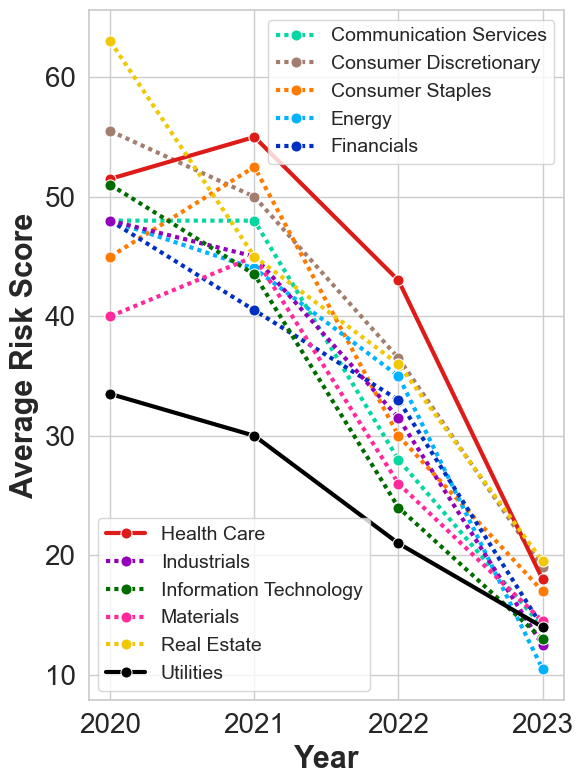

In [353]:
df_utilities = df_merged[df_merged['GICS_Sector'] == 'Utilities']
df_health_care = df_merged[df_merged['GICS_Sector'] == 'Health Care']

df_merged_other = df_merged[(df_merged['GICS_Sector'] != 'Utilities') & (df_merged['GICS_Sector'] != 'Health Care')]

avg_risk_by_sector = df_merged.groupby(['year', 'GICS_Sector'])['risk_score'].median().reset_index()

df_utilities = df_utilities.groupby('year')['risk_score'].median().reset_index()
df_health_care = df_health_care.groupby('year')['risk_score'].median().reset_index()


# 设置图表美学风格
sns.set_theme(style="whitegrid")

palette = ["#EE8575", "#F59D7C", "#FBB482", "#E4D597",
           "#CCF5AC", "#9CD7BC", "#91A9BB", "#867BB9",
           "#A48AAC", "#C1989E", "#AAD4A5"]

color_map = {
    'Health Care': "#DD1C1A",  
    'Utilities': "#000000BF",  
    'Consumer Discretionary': "#A27E6F", 
    'Consumer Staples': "#FF7B00", 
    'Real Estate': "#F0C808", 
    'Information Technology': "#006C00", 
    'Communication Services': "#06D6A0", 
    'Energy': "#00B2FF", 
    'Financials': "#0030C2", 
    'Industrials': "#9200BA", 
    'Materials': "#FF299C"
}

linestyle_map = {
    'Health Care': '',  # 实线
    'Utilities': '',  # 虚线
    'Consumer Discretionary': (1, 1), 
    'Consumer Staples': (1, 1), 
    'Real Estate': (1, 1), 
    'Information Technology': (1, 1), 
    'Communication Services': (1, 1), 
    'Energy': (1, 1), 
    'Financials': (1, 1), 
    'Industrials': (1, 1), 
    'Materials': (1, 1)
}

# 创建一个大一点的画布
fig, ax = plt.subplots(figsize=(6, 8))

lineplot_1 = sns.lineplot(
    data=avg_risk_by_sector,
    x='year',
    y='risk_score',
    hue='GICS_Sector',      # 根据行业区分【颜色】
    style='GICS_Sector',    # <--- 添加这一行！根据行业区分【线型】
    marker='o',
    markersize=8,
    linewidth=3,
    palette=color_map,
    alpha=1,
    zorder=1,
    dashes=linestyle_map    # <--- 保留这一行，它会为你自定义 style 参数应用的线型
)

# --- 添加图表美化元素 ---
# 添加标题和轴标签
# ax.set_title('Annual Average Risk Score by Sector', fontsize=22)
ax.set_xlabel('Year', fontsize=22, fontweight='bold')
ax.set_ylabel('Average Risk Score', fontsize=22, fontweight='bold')

# 确保x轴显示整数年份，例如 2020, 2021...
ax.set_xticks(avg_risk_by_sector['year'].unique())
ax.tick_params(axis='x', labelsize=20)
ax.tick_params(axis='y', labelsize=20)

# 调整图例位置，防止遮挡线条
# ax.legend(fontsize=16)

# -----------------------
# 2. 拆分 legend
# -----------------------
handles, labels = ax.get_legend_handles_labels()

# 示例：均分
split = len(labels) // 2
handles1, labels1 = handles[:split], labels[:split]
handles2, labels2 = handles[split:], labels[split:]

# 左下角 legend（轴外）
leg1 = ax.legend(
    handles1, labels1,
    loc='upper right',               # legend 框内的锚点位置  # 相对轴坐标 (0,0) 左下 (1,1) 右上
    frameon=True,
    ncol=1,
    fontsize=14
)

# 右上角 legend（轴外）
leg2 = ax.legend(
    handles2, labels2,
    loc='lower left',
    frameon=True,
    ncol=1,
    fontsize=14
)

# 防止第二个 legend 覆盖第一个
ax.add_artist(leg1)

# 调整布局以确保所有元素（如图例）都能完整显示
plt.tight_layout()
plt.savefig('annual_avg_risk_by_sector.pdf', dpi=600)  # 保存图表为图片文件

# 显示图表
plt.show()

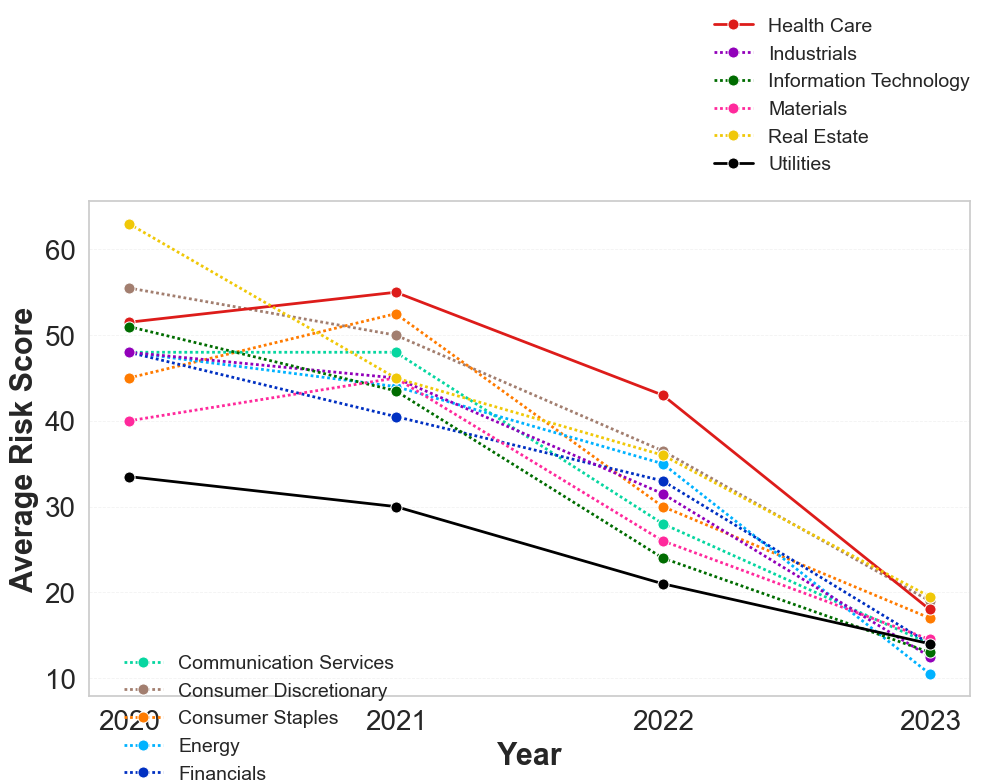

In [341]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.transforms import offset_copy

# -----------------------
# 1. 画图
# -----------------------
fig, ax = plt.subplots(figsize=(10, 8))

lineplot_1 = sns.lineplot(
    data=avg_risk_by_sector,
    x='year',
    y='risk_score',
    hue='GICS_Sector',      # 颜色
    style='GICS_Sector',    # 线型
    marker='o',
    markersize=8,
    linewidth=2,
    palette=color_map,
    alpha=1,
    zorder=1,
    dashes=linestyle_map,
    ax=ax
)

# 只保留横向网格线（可选）
ax.grid(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.25, linewidth=0.6)

# 轴标签
ax.set_xlabel('Year', fontsize=22, fontweight='bold')
ax.set_ylabel('Average Risk Score', fontsize=22, fontweight='bold')

# 刻度
ax.set_xticks(sorted(avg_risk_by_sector['year'].unique()))
ax.tick_params(axis='x', labelsize=20)
ax.tick_params(axis='y', labelsize=20)

# 去掉 seaborn 自动生成的 legend
if ax.get_legend() is not None:
    ax.get_legend().remove()

# -----------------------
# 2. 拆分 legend
# -----------------------
handles, labels = ax.get_legend_handles_labels()

# 示例：均分
split = len(labels) // 2
handles1, labels1 = handles[:split], labels[:split]
handles2, labels2 = handles[split:], labels[split:]

# 左下角 legend（轴外）
leg1 = ax.legend(
    handles1, labels1,
    loc='upper left',               # legend 框内的锚点位置
    bbox_to_anchor=(0.02, 0.12),  # 相对轴坐标 (0,0) 左下 (1,1) 右上
    frameon=False,
    ncol=1,
    fontsize=14
)

# 右上角 legend（轴外）
leg2 = ax.legend(
    handles2, labels2,
    loc='lower right',
    bbox_to_anchor=(1.02, 1.02),
    frameon=False,
    ncol=1,
    fontsize=14
)

# 防止第二个 legend 覆盖第一个
ax.add_artist(leg1)

# -----------------------
# 3. 布局 & 导出
# -----------------------
fig.subplots_adjust(left=0.1, right=0.8, bottom=0.12, top=0.95)  # 根据 legend 占位微调
plt.tight_layout()

plt.savefig('f1_gpr.pdf', dpi=600, bbox_inches='tight')  # bbox_inches 避免 legend 被裁
plt.show()


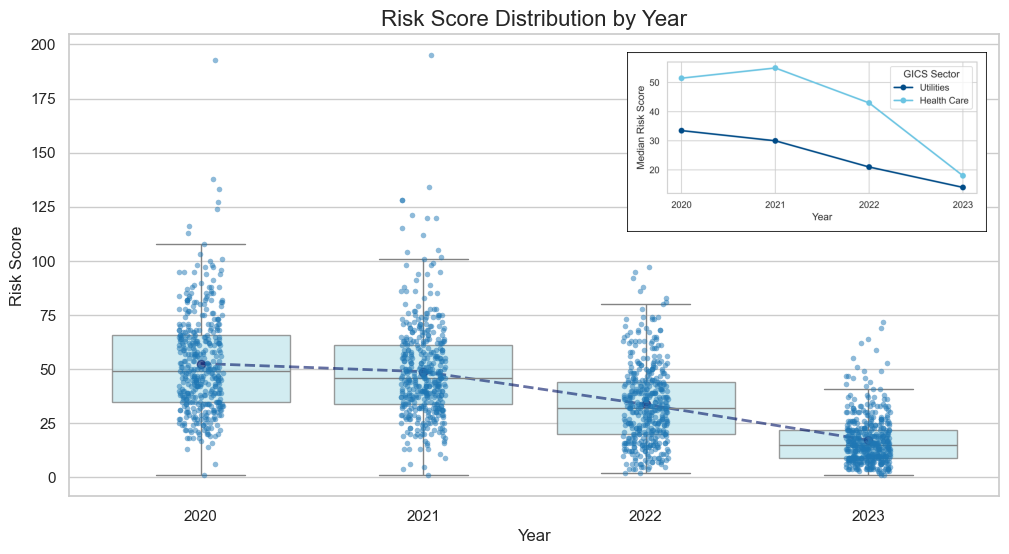

In [5]:
year_sorted = df_risk_scores.groupby('year')['year'].median().sort_values(ascending=True)
year_order = year_sorted.index

fig, ax = plt.subplots(figsize=(12, 6))
sns.set_theme(style="whitegrid") # 设置一个美观的背景主题

# 3. 绘制箱形图 (Box Plot) 作为底层
# 箱形图清晰地展示了中位数、上下四分位数(IQR)和主要的数据范围
sns.boxplot(
    x='year', 
    y='risk_score', 
    data=df_risk_scores, 
    order=year_order,  # 应用上面计算的排序
    showfliers=False,    # 隐藏箱形图自带的异常值点，因为我们将用抖动图绘制所有点
    boxprops=dict(alpha=0.8), # 设置箱体透明度，让视觉效果更好
    color="#C1ECF4" # 给箱体一个柔和的颜色
)

# 4. 在上层绘制抖动图 (Strip Plot / Jitter Plot)
# 抖动图展示了所有原始数据点的分布
sns.stripplot(
    x='year', 
    y='risk_score', 
    data=df_risk_scores, 
    order=year_order,  # 确保抖动图和箱形图的顺序一致
    jitter=True,         # 开启抖动
    alpha=0.5,           # 点的透明度，以显示重叠情况
    color="#1F77B4",    # 使用深色以突出数据点
    size=4               # 调整点的大小
)

# 3. --- 新增功能：计算并绘制每年均值趋势线 ---
# 按年份计算risk_score的均值
mean_scores = df_risk_scores.groupby('year')['risk_score'].mean().reindex(year_order)

# 在图上绘制均值趋势线
# 我们使用 plt.plot 来创建线条。x轴需要是数值位置（0, 1, 2...），y轴是均值。
ax.plot(range(len(mean_scores)), mean_scores,
         color="#00136699",           # 线条颜色
         marker='o',            # 标记点样式
         linestyle='--',       # 线条样式
         linewidth=2,           # 线条宽度
         label='年度均值')      # 图例标签

# 1. 读取你的PNG图片
# !!!重要!!!: 请将 'your_logo.png' 替换成你的图片文件路径
logo_path = 'sector_risk_trend_with_frame.png'
logo = mpimg.imread(logo_path)

# 2. 定义图片在图表中的位置和大小
# [left, bottom, width, height]，所有值都是相对于图表总尺寸的比例 (0到1)
# 例如 [0.8, 0.8, 0.1, 0.1] 表示从左边80%、底部80%开始，宽高都是图表的10%
image_box = fig.add_axes([0.59, 0.55, 0.3, 0.3], anchor='NE', zorder=10)
image_box.imshow(logo)
image_box.axis('off')

ax.tick_params(axis='x', labelsize=11)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Risk Score', fontsize=12)
ax.set_title('Risk Score Distribution by Year', fontsize=16)

# plt.tight_layout() # 调整布局，为右上角的logo留出空间
plt.savefig(f'GICS_Sector_Risk_Score_Yearly_with_Logo.png', dpi=300)
plt.show()

/var/folders/f2/4wvlw_2n48ncjhv0cwccstmc0000gn/T/ipykernel_49750/80812020.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  vp = sns.violinplot(
/var/folders/f2/4wvlw_2n48ncjhv0cwccstmc0000gn/T/ipykernel_49750/80812020.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/f2/4wvlw_2n48ncjhv0cwccstmc0000gn/T/ipykernel_49750/80812020.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


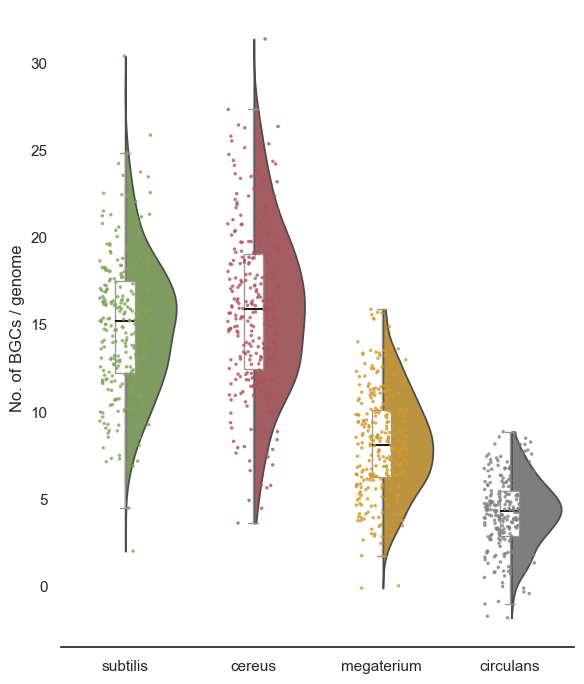

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import PathPatch

# -----------------------------
# 1. 造示例数据
# -----------------------------
np.random.seed(42)
cats = ["subtilis", "cereus", "megaterium", "circulans"]
n_per_cat = 300
data = {
    "species": np.repeat(cats, n_per_cat),
    "bgc_per_genome": np.hstack([
        np.random.normal(loc=15, scale=4, size=n_per_cat),
        np.random.normal(loc=16, scale=5, size=n_per_cat),
        np.random.normal(loc=8,  scale=3, size=n_per_cat),
        np.random.normal(loc=4,  scale=2, size=n_per_cat)
    ])
}
df = pd.DataFrame(data)

# -----------------------------
# 2. 颜色 & 基本风格
# -----------------------------
palette = ["#7FA557", "#AE5259", "#CF992C", "#7E7E7E"]
sns.set_theme(style="white")   # 去掉背景网格

fig, ax = plt.subplots(figsize=(6, 7))

# -----------------------------
# 3. 画完整 violin，再裁成半边
# -----------------------------
vp = sns.violinplot(
    x="species", y="bgc_per_genome", data=df,
    palette=palette, ax=ax, cut=0, inner=None
)

# 将每条 violin 的 patch 剪掉左半边
for violin in vp.collections:
    # 复制 Path，方便操作
    path = violin.get_paths()[0]
    verts = path.vertices
    # verts[:,0] 是 X 坐标，取中位数（竖向 violin 的中心线）
    mid_x = np.median(verts[:, 0])
    # 保留 verts.x >= mid_x 这一半
    verts[:,0] = np.where(verts[:,0] < mid_x, mid_x, verts[:,0])

# -----------------------------
# 4. 叠 boxplot
# -----------------------------
sns.boxplot(
    x="species", y="bgc_per_genome", data=df,
    width=0.15, ax=ax, showcaps=True, boxprops={"zorder":2, "linewidth":1},
    whiskerprops={"linewidth":1}, medianprops={"linewidth":1.5, "color":"k"},
    showfliers=False, palette=["white"]*4,
)

# -----------------------------
# 5. 叠散点（点云）
# -----------------------------
sns.stripplot(
    x="species", y="bgc_per_genome", data=df,
    ax=ax, size=2.5, jitter=0.2, palette=palette, linewidth=0,
    edgecolor=None, alpha=0.8
)

# -----------------------------
# 6. 美化坐标轴
# -----------------------------
ax.set_xlabel("")
ax.set_ylabel("No. of BGCs / genome")
sns.despine(left=True)

plt.tight_layout()
plt.show()


In [163]:
20 / 0.57

35.08771929824562